# Concept-Token Probability Mass Check

This notebook computes a small quantitative suppression metric from `suppression_report.json`.

For each generation prompt, it measures concept-token probability mass

$$m_t = \sum_{v \in V_{concept}} p_t(v)$$

and compares clean vs clamped model behavior on continuation positions.

$$\Delta m = \frac{1}{T} \sum_{t = 1}^{T} (m_{t}^{supp} - m_{t}^{clean})$$

If suppression works, we typically want $\Delta m<0$ on concept-target prompts, while non-concept prompts stay near 0.

In [2]:
from pathlib import Path
import json

import torch
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

import sys
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(repo_root))

from sae import SAE, SAEConfig
from sae.hooks import patch_residual_stream
from sae.intervene import make_clamp_fn

In [7]:
# Update these values
report_path = repo_root / "runs/gemma2b_mid_pile_topk_8d/run_1/suppress_golden_gate/suppression_report.json"
concept_terms = ["Golden Gate", "Bridge", "San Francisco"]

# Optional overrides
compute_dtype = "bfloat16"   # one of: float16, bfloat16, float32
device = "cuda" if torch.cuda.is_available() else "cpu"

In [8]:
def load_sae(ckpt_path: Path, device: str, dtype: torch.dtype):
    payload = torch.load(ckpt_path, map_location="cpu")
    sae_cfg = SAEConfig(**payload["sae_cfg"])

    sae = SAE(sae_cfg)
    sae.load_state_dict(payload["sae_state"])

    sae.to(device=device, dtype=dtype)
    sae.eval()
    return sae

def resolve_repo_path(path_str: str | Path) -> Path:
    path = Path(path_str)
    if path.is_absolute():
        return path
    return (repo_root / path).resolve()

def build_concept_token_ids(tokenizer, terms):
    variants = set()
    for t in terms:
        t = t.strip()
        if not t:
            continue
        variants.add(t)
        variants.add(" " + t)
        variants.add(t.lower())
        variants.add(" " + t.lower())
        variants.add(t.title())
        variants.add(" " + t.title())

    token_ids = set()
    for v in variants:
        ids = tokenizer.encode(v, add_special_tokens=False)
        for tid in ids:
            token_ids.add(int(tid))

    if not token_ids:
        raise ValueError("No concept token ids collected. Check concept_terms.")
    return sorted(token_ids)

def continuation_prediction_slice(full_ids, prompt_ids):
    # logits index i predicts token at position i+1
    # first continuation token is at absolute token index len(prompt_ids)
    # so first prediction index is len(prompt_ids)-1
    start = max(len(prompt_ids) - 1, 0)
    stop = max(len(full_ids) - 1, 0)
    if stop <= start:
        return slice(0, 0)
    return slice(start, stop)

@torch.no_grad()
def concept_mass_curve(model, input_ids, concept_token_ids):
    out = model(input_ids=input_ids, use_cache=False)
    logits = out.logits[:, :-1, :].float()
    probs = torch.softmax(logits, dim=-1)
    mass = probs[..., concept_token_ids].sum(dim=-1).squeeze(0)
    return mass

def token_ids(text, tokenizer):
    return tokenizer.encode(text, add_special_tokens=True, truncation=True, max_length=1024)

In [9]:
with open(report_path, "r") as f:
    report = json.load(f)

dtype_map = {
    "float16": torch.float16,
    "bfloat16": torch.bfloat16,
    "float32": torch.float32,
}
dtype = dtype_map[compute_dtype]

layer_idx = int(report["layer_idx"])
feature_ids = [int(x["feature_id"]) for x in report["features"]]
clamp_value = float(report.get("clamp_value", 0.0))
ckpt_path = resolve_repo_path(report["ckpt"])

tokenizer = AutoTokenizer.from_pretrained(report["model"])
model = AutoModelForCausalLM.from_pretrained(report["model"], torch_dtype=dtype).to(device)
model.eval()

sae = load_sae(ckpt_path, device=device, dtype=dtype)
clamp_fn = make_clamp_fn(sae, feature_ids, clamp_values=clamp_value)

concept_token_ids = build_concept_token_ids(tokenizer, concept_terms)
print("Model:", report["model"])

print("Layer:", layer_idx)
print("Checkpoint:", ckpt_path)
print("Clamped features:", feature_ids)
print("Concept token count:", len(concept_token_ids))

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 288/288 [00:00<00:00, 750.19it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 42.00 MiB. GPU 0 has a total capacity of 47.53 GiB of which 3.06 MiB is free. Process 87402 has 43.68 GiB memory in use. Including non-PyTorch memory, this process has 3.83 GiB memory in use. Of the allocated memory 3.45 GiB is allocated by PyTorch, and 134.72 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [5]:
rows = []

for i, g in enumerate(report["generations"], start=1):
    prompt = g["prompt"]
    clean_text = g["clean"]

    prompt_ids = token_ids(prompt, tokenizer)
    clean_ids = token_ids(clean_text, tokenizer)

    s = continuation_prediction_slice(clean_ids, prompt_ids)
    if s.stop <= s.start:
        rows.append({
            "example_idx": i,
            "prompt": prompt,
            "n_cont_positions": 0,
            "clean_mean_mass": float("nan"),
            "suppressed_mean_mass": float("nan"),
            "delta_mean_mass": float("nan"),
        })
        continue

    input_ids = torch.tensor(clean_ids, device=device).unsqueeze(0)

    mass_clean = concept_mass_curve(model, input_ids, concept_token_ids)
    with patch_residual_stream(model, layer_idx, clamp_fn):
        mass_supp = concept_mass_curve(model, input_ids, concept_token_ids)

    mean_clean = float(mass_clean[s].mean().item())
    mean_supp = float(mass_supp[s].mean().item())

    rows.append({
        "example_idx": i,
        "prompt": prompt,
        "n_cont_positions": int(s.stop - s.start),
        "clean_mean_mass": mean_clean,
        "suppressed_mean_mass": mean_supp,
        "delta_mean_mass": mean_supp - mean_clean,
    })

df = pd.DataFrame(rows)
display(df)

summary = {
    "report_path": str(report_path),
    "concept_terms": concept_terms,
    "n_examples": int(len(df)),
    "mean_clean_mass": float(df["clean_mean_mass"].mean()),
    "mean_suppressed_mass": float(df["suppressed_mean_mass"].mean()),
    "mean_delta_mass": float(df["delta_mean_mass"].mean()),
    "median_delta_mass": float(df["delta_mean_mass"].median()),
}

print(json.dumps(summary, indent=2))

,example_idx,prompt,n_cont_positions,clean_mean_mass,suppressed_mean_mass,delta_mean_mass
0,1,The Golden Gate Bridge is,40,1.421145e-01,1.357309e-01,-6.383553e-03
1,2,San Francisco is famous for its,40,6.045078e-03,5.318922e-03,-7.261564e-04
2,3,I had pasta for dinner and,40,1.122131e-07,1.029991e-07,-9.213956e-09


{
  "report_path": "/home/doomfist/Documents/Research/Unlearning/mech_interpretability/sae_on_llm/runs/gemma2b_mid_pile_topk/run_1/suppress_golden_gate/suppression_report.json",
  "concept_terms": [
    "Golden Gate",
    "Bridge",
    "San Francisco"
  ],
  "n_examples": 3,
  "mean_clean_mass": 0.04938655035813847,
  "mean_suppressed_mass": 0.047016644103588114,
  "mean_delta_mass": -0.002369906254550358,
  "median_delta_mass": -0.0007261564023792744
}


In [6]:
out_dir = report_path.parent
table_path = out_dir / "concept_mass_by_prompt.csv"
summary_path = out_dir / "concept_mass_summary.json"

df.to_csv(table_path, index=False)
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Wrote:", table_path)
print("Wrote:", summary_path)

Wrote: /home/doomfist/Documents/Research/Unlearning/mech_interpretability/sae_on_llm/runs/gemma2b_mid_pile_topk/run_1/suppress_golden_gate/concept_mass_by_prompt.csv
Wrote: /home/doomfist/Documents/Research/Unlearning/mech_interpretability/sae_on_llm/runs/gemma2b_mid_pile_topk/run_1/suppress_golden_gate/concept_mass_summary.json


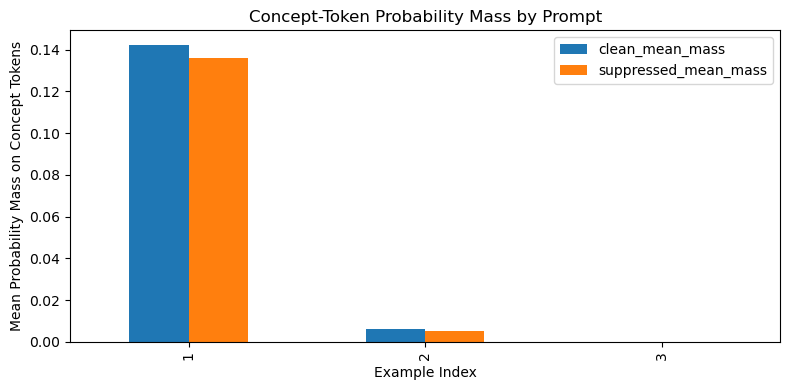

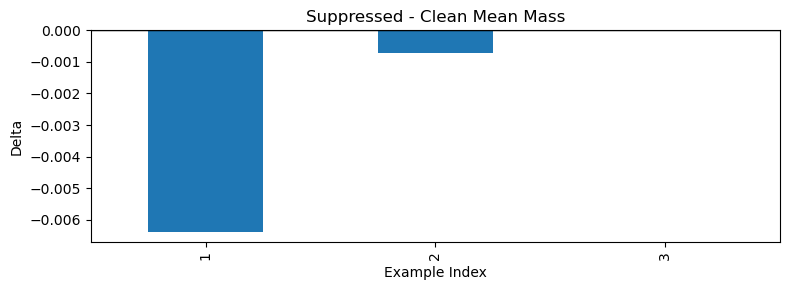

In [7]:
ax = df.plot(kind="bar", x="example_idx", y=["clean_mean_mass", "suppressed_mean_mass"], figsize=(8, 4))
ax.set_title("Concept-Token Probability Mass by Prompt")
ax.set_xlabel("Example Index")
ax.set_ylabel("Mean Probability Mass on Concept Tokens")
plt.tight_layout()
plt.show()

ax = df.plot(kind="bar", x="example_idx", y="delta_mean_mass", figsize=(8, 3), legend=False)
ax.axhline(0.0, color="black", linewidth=1)
ax.set_title("Suppressed - Clean Mean Mass")
ax.set_xlabel("Example Index")
ax.set_ylabel("Delta")
plt.tight_layout()
plt.show()

## Pass/Fail Heuristic
Pass if `mean_delta_mass < -0.005`; fail otherwise 

(closer to 0 or positive means suppression did not reduce concept-token probability mass enough; more negative is better suppression).